In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import time
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print (tf.__version__)


2.19.0


In [53]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
train = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_test.csv")

print(train.shape)
print(test.shape)

(27455, 785)
(7172, 785)


In [55]:
x_train_full = train.drop('label', axis = 1).values
y_train_full = train['label'].values

x_test = test.drop('label', axis = 1).values
y_test = test['label'].values

x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full,
    test_size = 0.2, random_state = 42, stratify = y_train_full)

num_classes = 25
y_train = to_categorical(y_train, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test = to_categorical(y_test, num_classes)

class_names = [chr (i) for i in range (65,91) if chr(i) not in ('J', 'Z')]

print(f"Train: {x_train.shape[0]} | valid: {x_valid.shape[0]} | test: {x_test.shape[0]}")
print("Classes:", class_names)

Train: 21964 | valid: 5491 | test: 7172
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


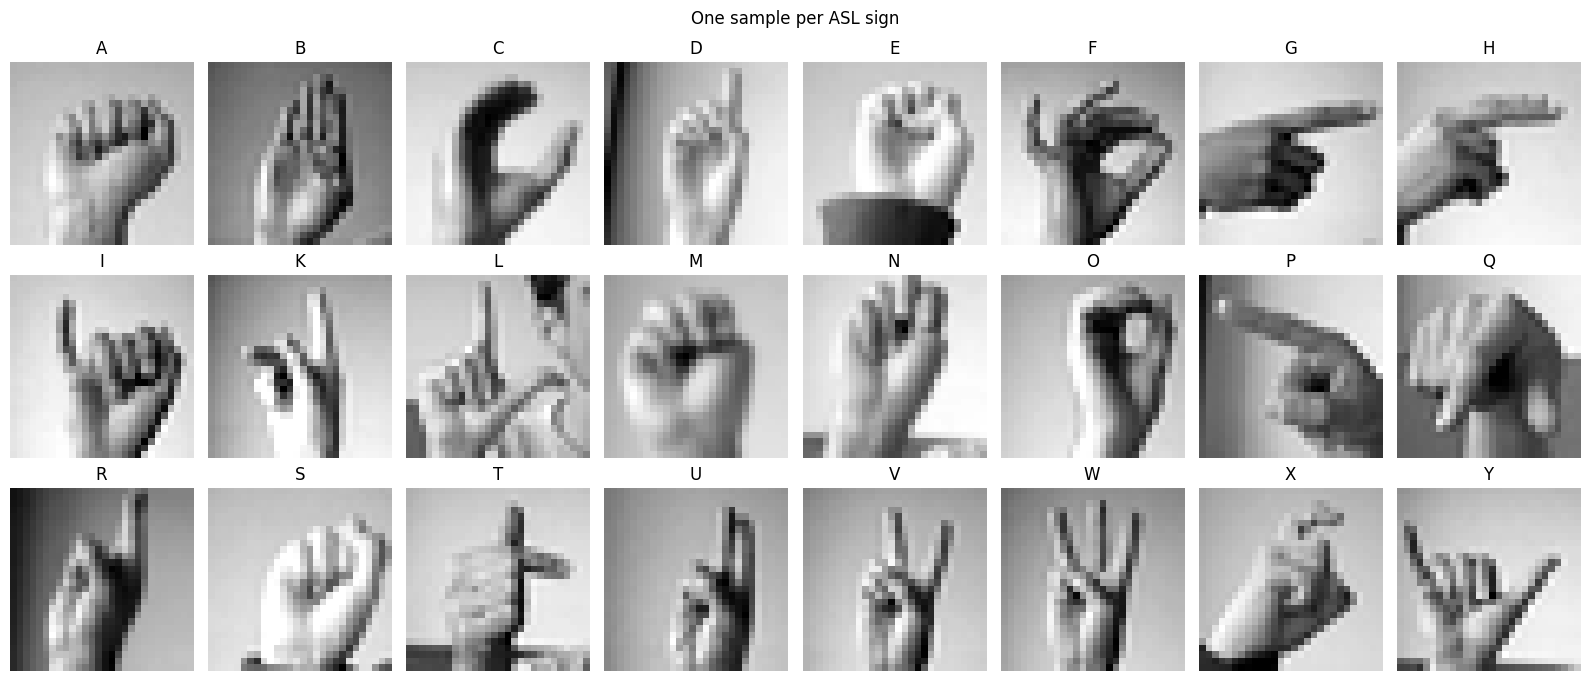

In [56]:
unique_labels = np.unique(y_train.argmax(axis = 1))

fig, axes = plt.subplots(3, 8, figsize = (16, 7))
axes = axes.flatten()

for i, class_name_char in enumerate(class_names):
  # Determine the actual numeric label value corresponding to the i-th class_name
  actual_label_value = i
  if i >= 9: # Account for the skipped 'J' (label 9)
    actual_label_value += 1

  sample = np.where(y_train.argmax(axis = 1) == actual_label_value)[0][0]
  axes[i].imshow(x_train[sample].squeeze(), cmap = 'gray')
  axes[i].set_title(class_name_char)
  axes[i].axis('off')

plt.suptitle("One sample per ASL sign")
plt.tight_layout()
plt.show()

In [57]:
model_baseline = models.Sequential([
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax')
])

model_baseline.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,577 (1.62 MB)

 Trainable params: 423,577 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
callbacks = [
    EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

start = time.time()

history_baseline = model_baseline.fit(
    x_train, y_train,
    validation_data = (x_valid, y_valid),
    epochs = 50,
    batch_size = 256,
    callbacks = callbacks,
    verbose = 1
)

baseline_time = round(time.time() - start)
print(f"Training time: {baseline_time} seconds")

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.2167 - loss: 2.6476 - val_accuracy: 0.6298 - val_loss: 1.5168 - learning_rate: 0.0010
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5727 - loss: 1.3395 - val_accuracy: 0.8600 - val_loss: 0.6276 - learning_rate: 0.0010
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7298 - loss: 0.8229 - val_accuracy: 0.9224 - val_loss: 0.3425 - learning_rate: 0.0010
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8058 - loss: 0.5724 - val_accuracy: 0.9689 - val_loss: 0.1868 - learning_rate: 0.0010
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8585 - loss: 0.4195 - val_accuracy: 0.9734 - val_loss: 0.1374 - learning_rate: 0.0010
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8925 - loss: 0.3239 - val_accuracy: 0.9927 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9144 - loss: 0.2563 - val_accuracy

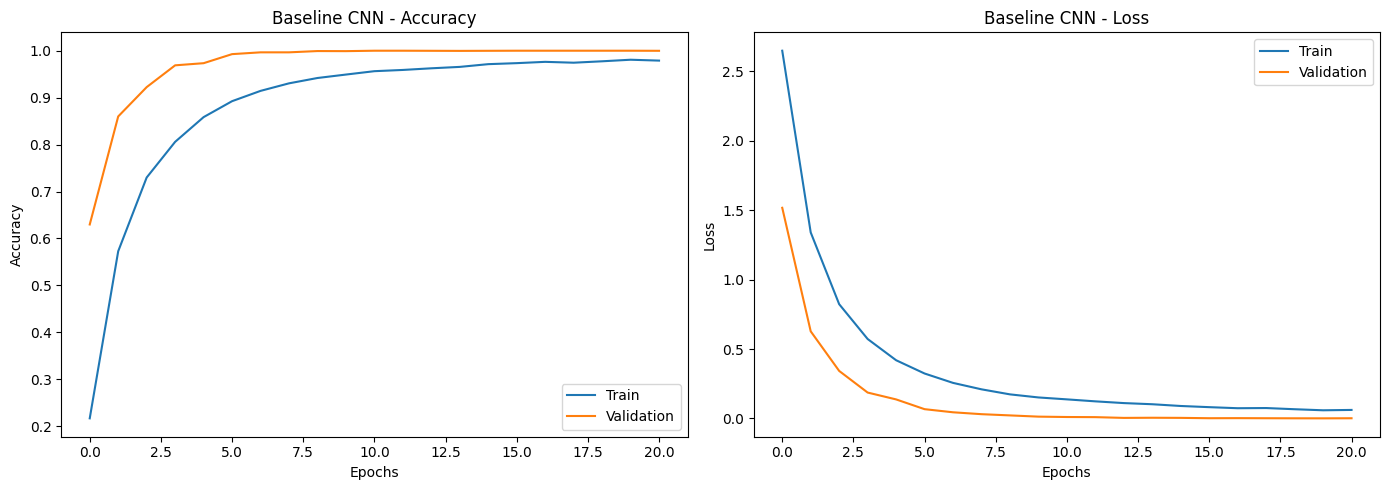

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.plot(history_baseline.history['accuracy'], label = 'Train')
ax1.plot(history_baseline.history['val_accuracy'], label = 'Validation')
ax1.set_title('Baseline CNN - Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_baseline.history['loss'], label = 'Train')
ax2.plot(history_baseline.history['val_loss'], label = 'Validation')
ax2.set_title('Baseline CNN - Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [60]:
model_enhanced = models.Sequential([
    layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1 )),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax'),

])

model_enhanced.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_58 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 438,585 (1.67 MB)

 Trainable params: 437,561 (1.67 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [61]:
fresh_callbacks = [
    EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

model_enhanced = models.Sequential([
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax'),

])

model_enhanced.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

start = time.time()
history_enhanced = model_enhanced.fit(
    x_train, y_train,
    validation_data = (x_valid, y_valid),
    epochs = 50,
    batch_size = 256,
    callbacks = fresh_callbacks,
    verbose = 1
)

enhanced_time = round(time.time() - start)
print(f"Training time: {enhanced_time} seconds")


Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.4776 - loss: 1.7042 - val_accuracy: 0.0424 - val_loss: 4.0217 - learning_rate: 0.0010
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9447 - loss: 0.1898 - val_accuracy: 0.0683 - val_loss: 4.5657 - learning_rate: 0.0010
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9915 - loss: 0.0386 - val_accuracy: 0.0503 - val_loss: 5.0587 - learning_rate: 0.0010
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9960 - loss: 0.0179 - val_accuracy: 0.2080 - val_loss: 3.7347 - learning_rate: 0.0010
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9981 - loss: 0.0099 - val_accuracy: 0.7452 - val_loss: 0.8385 - learning_rate: 0.0010
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9993 - loss: 0.0060 - val_accuracy: 0.9539 - val_loss: 0.1406 - learning_rate: 0.0010
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9990 - loss: 0.0055 - val_a

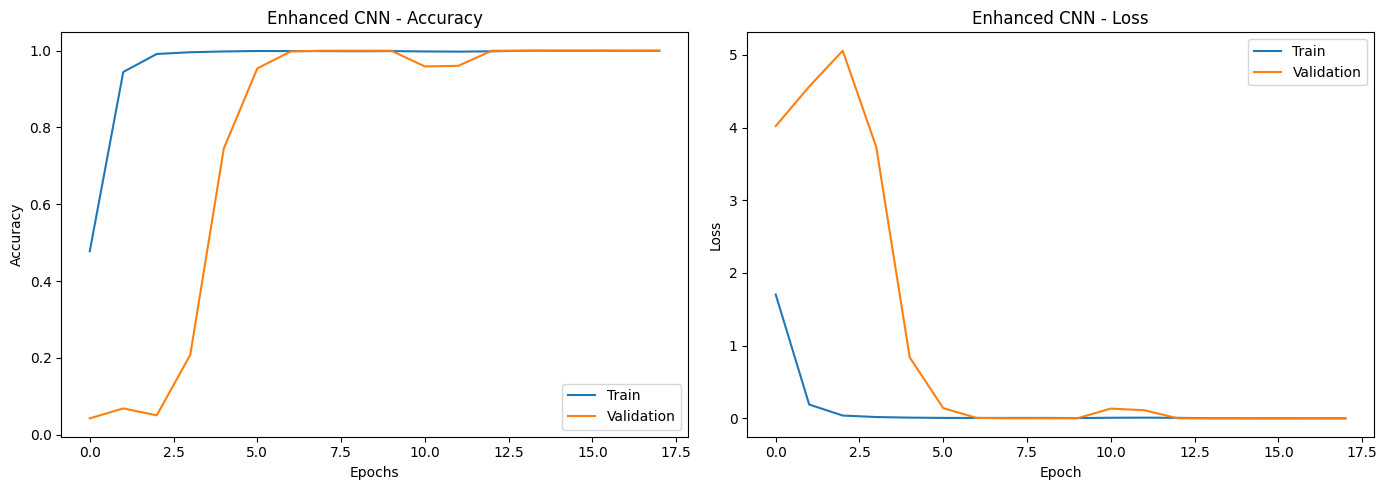

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.plot(history_enhanced.history['accuracy'], label = 'Train')
ax1.plot(history_enhanced.history['val_accuracy'], label = 'Validation')
ax1.set_title('Enhanced CNN - Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_enhanced.history['loss'], label = 'Train')
ax2.plot(history_enhanced.history['val_loss'], label = 'Validation')
ax2.set_title('Enhanced CNN - Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [63]:
baseline_loss, baseline_accuracy = model_baseline.evaluate(x_test, y_test, verbose = 0)
enhanced_loss, enhanced_accuracy = model_enhanced.evaluate(x_test, y_test, verbose = 0)

print("Model comparision on test set")
print("==============================")
print(f"Baseline - Accuracy: {baseline_accuracy*100:.2f} | Loss: {baseline_loss:.4f}")
print(f"Enhanced - Accuracy: {enhanced_accuracy*100:.2f} | Loss: {enhanced_loss:.4f}")
print(f"Baseline - Params: {model_baseline.count_params():,}")
print(f"Enhanced - Params: {model_enhanced.count_params():,}")
print(f"Baseline - Time: {baseline_time} seconds")
print(f"Enhanced - Time: {enhanced_time} seconds")

Model comparision on test set
Baseline - Accuracy: 91.44 | Loss: 0.2978
Enhanced - Accuracy: 99.34 | Loss: 0.0190
Baseline - Params: 423,577
Enhanced - Params: 438,585
Baseline - Time: 26 seconds
Enhanced - Time: 64 seconds


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


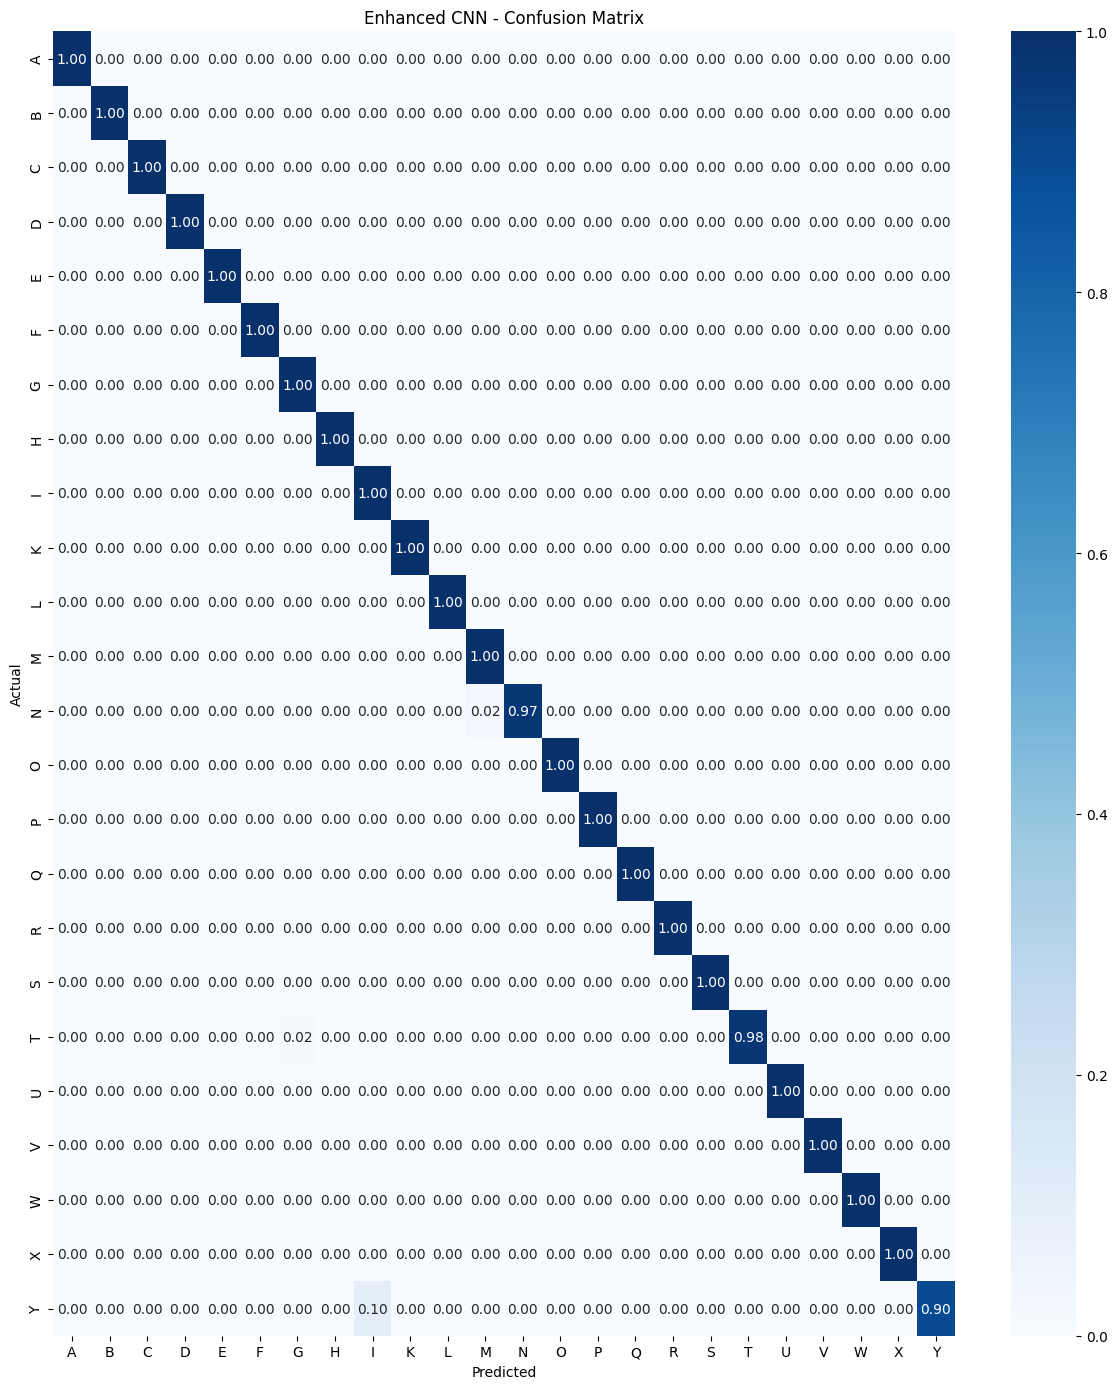

In [73]:
from sklearn.utils import column_or_1d
y_pred = model_enhanced.predict (x_test)
y_pred_classes = np.argmax(y_pred, axis = 1)
y_test_classes = np.argmax(y_test, axis = 1)

cm = confusion_matrix(y_test_classes, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

plt.figure(figsize = (12, 14))
sns.heatmap(cm_normalized, annot = True, fmt = '.2f', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names)
plt.title('Enhanced CNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [75]:
print("Classification Report - Baseline CNN")
print("="*50)
y_pred_baseline = model_baseline.predict(x_test)
y_pred_baseline_classes = np.argmax(y_pred_baseline, axis = 1)
print(classification_report(y_test_classes, y_pred_baseline_classes, target_names = class_names))

print ("Classification Report - Enhanced CNN")
print("="*50)
print(classification_report(y_test_classes, y_pred_classes, target_names = class_names))

Classification Report - Baseline CNN
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           A       0.98      1.00      0.99       331
           B       1.00      0.95      0.97       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       0.92      0.93      0.93       498
           F       1.00      1.00      1.00       247
           G       0.94      0.88      0.91       348
           H       0.94      0.95      0.95       436
           I       0.86      0.82      0.84       288
           K       0.93      0.94      0.94       331
           L       0.86      1.00      0.93       209
           M       0.91      0.86      0.89       394
           N       1.00      0.89      0.94       291
           O       1.00      1.00      1.00       246
           P       0.90      1.00      0.95       347
           Q       0.98      1.00      0.99       164
   

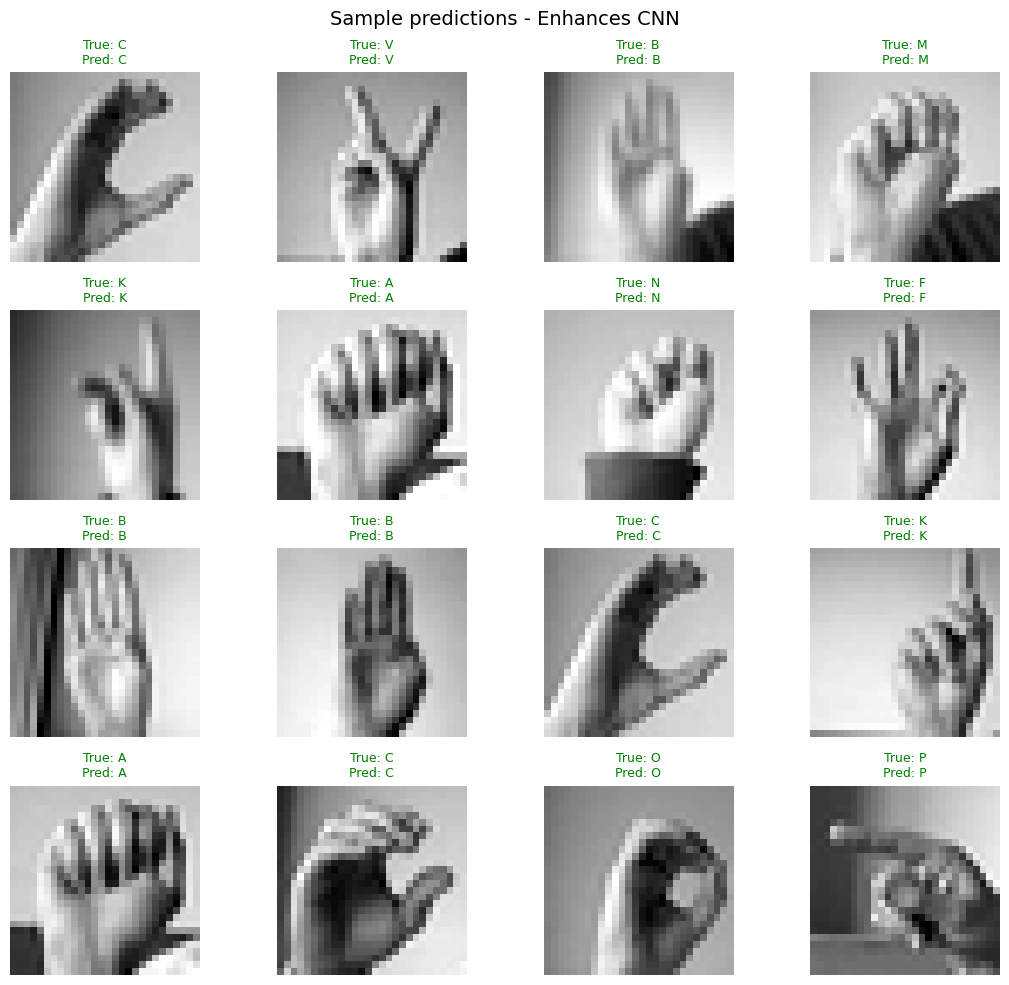

In [66]:
fig, axes = plt.subplots(4, 4, figsize = (11,10))
axes = axes.flatten()

indices = np.random.choice(len(x_test), 16, replace = False)

for i, idx in enumerate(indices):
  axes[i].imshow(x_test[idx].squeeze(), cmap = 'gray')

  true_label_numeric = y_test_classes[idx]
  pred_label_numeric = y_pred_classes[idx]

  # Map the numeric labels to the correct index in class_names.
  # The original labels skip 'J' (numeric label 9).
  # So, if a numeric label is for 'K' or later (numeric label 10 or more),
  # it needs to be decremented by 1 to get the correct index in `class_names`.
  true_label_mapped_idx = true_label_numeric
  if true_label_numeric > 8: # If numeric label is 9 (J) or higher, its class_names index is shifted.
    true_label_mapped_idx -= 1 # Since J (numeric label 9) is skipped, K (numeric label 10) becomes index 9.

  pred_label_mapped_idx = pred_label_numeric
  if pred_label_numeric > 8:
    pred_label_mapped_idx -= 1

  true_label = class_names[true_label_mapped_idx]
  pred_label = class_names[pred_label_mapped_idx]

  color = 'green' if true_label == pred_label else 'red'
  axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color = color, fontsize = 9)
  axes[i].axis('off')

plt.suptitle("Sample predictions - Enhances CNN", fontsize = 14)
plt.tight_layout()
plt.show()